处理`_PDStrain3DVali.py`的结果，分析PD的动态仿真过程与准静态过程的差距，差距小能说明近似为准静态过程是合理的。

使用liver.msh文件，固定[3, 39, 64]，移动[85]

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, ScalarFormatter, FuncFormatter
from matplotlib.gridspec import GridSpec

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [2]:
node_pos_init = np.loadtxt('pos_init.csv', delimiter=',')
node_pos_before = np.loadtxt('pos_before.csv', delimiter=',')
node_pos_after = np.loadtxt('pos_after_200.csv', delimiter=',')

before_movement = node_pos_before - node_pos_init
after_movement = node_pos_after - node_pos_init

cos_error = []
nmse = []
error = []
rel_error = []

for i in range(len(before_movement)):
    if np.linalg.norm(before_movement[i]) < 1e-4 or np.linalg.norm(after_movement[i]) < 1e-4:
        nmse.append(0.)
        error.append(0.)
        rel_error.append(0.)
        continue
    # cos_error.append(np.dot(before_movement[i], after_movement[i]) / (np.linalg.norm(before_movement[i]) * np.linalg.norm(after_movement[i])))
    error.append(np.linalg.norm(before_movement[i] - after_movement[i]))
    rel_error.append(np.linalg.norm(before_movement[i] - after_movement[i]) / np.linalg.norm(before_movement[i]))
    nmse.append(np.sqrt(np.sum((before_movement[i] - after_movement[i])**2) / np.sum(before_movement[i]**2 + after_movement[i]**2)))
    # rel_error.append(np.linalg.norm(before_movement[i] - after_movement[i]) / np.linalg.norm(before_movement[i]))

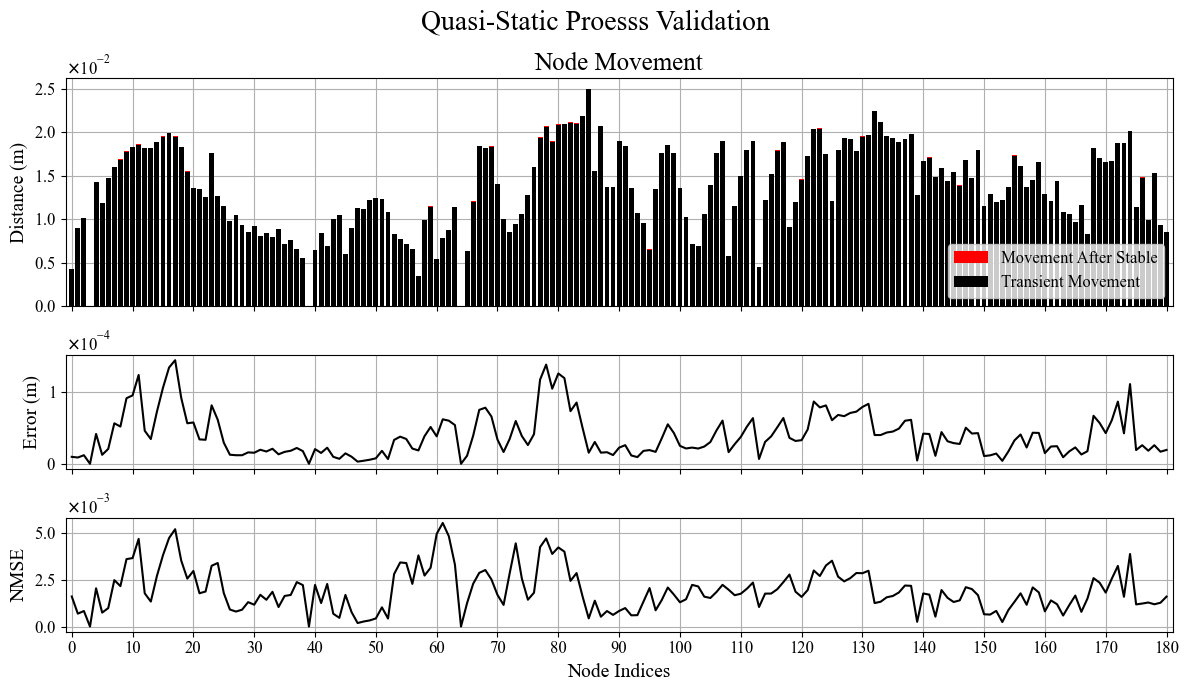

In [16]:
"""
绘制瞬态变形与稳定变形的差异
"""
# fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True, sharey=False)
fig = plt.figure(figsize=(12, 7), dpi=100)
gs = GridSpec(3, 1, figure=fig, height_ratios=[2, 1, 1])

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))

fig.suptitle('Quasi-Static Proesss Validation', fontsize=20, fontname='Times New Roman')

axs_movement = fig.add_subplot(gs[0])
axs_error = fig.add_subplot(gs[1], sharex=axs_movement)
axs_nmse = fig.add_subplot(gs[2], sharex=axs_movement)
# axs_rel_error = fig.add_subplot(gs[3], sharex=axs_movement)

# axs_movement.plot(np.linalg.norm(before_movement, axis=1), c='k', lw=1.5, label='Before Movement')
# axs_movement.plot(np.linalg.norm(after_movement, axis=1), c='r', lw=1.5, label='After Movement')
axs_movement.bar(range(len(after_movement)), np.linalg.norm(after_movement, axis=1), color='r', label='Movement After Stable', zorder=2)
axs_movement.bar(range(len(before_movement)), np.linalg.norm(before_movement, axis=1), color='k', label='Transient Movement', zorder=3)
axs_movement.set_title('Node Movement', fontsize=18)
# axs_movement.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
axs_movement.set_ylabel('Distance (m)', fontsize=14, fontname='Times New Roman')
axs_movement.set_xlim([-1, len(before_movement)])
axs_movement.xaxis.set_major_locator(MultipleLocator(10))
axs_movement.legend(loc='lower right', fontsize=12)

axs_error.plot(error, c='k', lw=1.5, label='Error')
# axs_error.set_title('Error', fontsize=18)
# axs_error.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
axs_error.set_ylabel('Error (m)', fontsize=14, fontname='Times New Roman')
axs_error.set_xlim([-1, len(error)])
axs_error.xaxis.set_major_locator(MultipleLocator(10))

axs_nmse.plot(nmse, c='k', lw=1.5, label='NMSE')
# axs_nmse.set_title('Error in Approximating Dynamic Processes as Quasi-Static Processes', fontsize=18, fontname='Times New Roman')
axs_nmse.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
axs_nmse.set_ylabel('NMSE', fontsize=14, fontname='Times New Roman')
axs_nmse.set_xlim([-1, len(nmse)])
axs_nmse.xaxis.set_major_locator(MultipleLocator(10))

# axs_rel_error.plot(rel_error, c='k', lw=1.5, label='Relative Error')
# # axs_rel_error.set_title('Relative Error', fontsize=18)
# axs_rel_error.set_xlabel('Node Indices', fontsize=14, fontname='Times New Roman')
# axs_rel_error.set_ylabel('Relative Error', fontsize=14, fontname='Times New Roman')
# axs_rel_error.set_xlim([-1, len(rel_error)])
# axs_rel_error.xaxis.set_major_locator(MultipleLocator(10))

# axs = [axs_movement, axs_nsme, axs_error, axs_rel_error]
axs = [axs_movement, axs_error, axs_nmse]
for ax in axs:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useLocale=False, useMathText=True)
    ax.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
    ax.yaxis.offsetText.set_fontsize(12)                      # 设置坐标轴中科学计数法中的指数大小
    ax.grid('True', zorder=-1)
    ax.label_outer()                                          # 只显示最外层的坐标轴标签

plt.tight_layout()
plt.show()

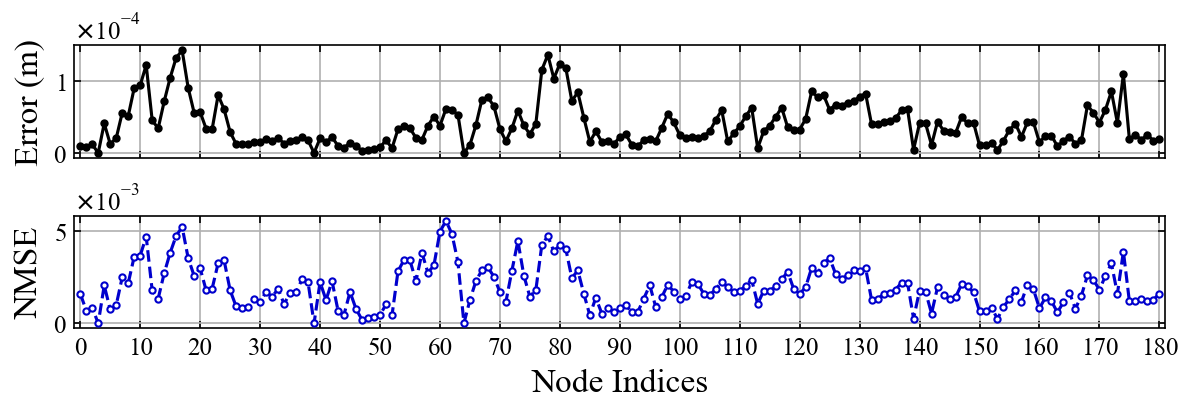

In [127]:
# 用于论文的作图
fig = plt.figure(figsize=(8, 2.8), dpi=150)
gs = GridSpec(2, 1, figure=fig)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))

axs_error = fig.add_subplot(gs[0])
axs_error.plot(error, marker='.', c='k', lw=1.5, label='Error', zorder=3)
axs_error.set_ylabel('Error (m)', fontsize=16)
axs_error.set_xlabel('Node Indices', fontsize=16, fontname='Times New Roman')
axs_error.set_xlim([-1, len(error)])
# axs_error.set_ylim([0., 1.5e-4])
axs_error.xaxis.set_major_locator(MultipleLocator(10))
# axs_error.grid('True', zorder=-1)

# axs_nmse = axs_error.twinx()
axs_nmse = fig.add_subplot(gs[1], sharex=axs_error)
axs_nmse.plot(nmse, marker='.', markerfacecolor='white', linestyle='--', color='mediumblue', lw=1.5, label='NMSE', zorder=3)
axs_nmse.set_xlabel('Node Indices', fontsize=16, fontname='Times New Roman')
axs_nmse.set_ylabel('NMSE', fontsize=16, fontname='Times New Roman')
# axs_nmse.set_ylim([0., 6.e-3])

# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(0.95, 1), bbox_transform=axs_error.transAxes)

axs = [axs_error, axs_nmse]
for ax in axs:
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useLocale=False, useMathText=True)
    ax.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
    ax.yaxis.offsetText.set_fontsize(12)                      # 设置坐标轴中科学计数法中的指数大小
    ax.label_outer()                                          # 只显示最外层的坐标轴标签
    ax.grid('True', zorder=-1)
    ax.tick_params(axis='both', direction='in', top=True, right=True)
    ax.set_axisbelow(True)
    # ax.set_ylim(bottom=0.)

plt.tight_layout()
fig.savefig('quasi-static.pdf', transparent=True, dpi=300, bbox_inches='tight')

In [92]:
sample_pos_np = np.loadtxt('sample_pos.csv', delimiter=',')
sample_pos_init = sample_pos_np[0, :]
sample_pos_x = sample_pos_np[:, 0]
sample_pos_y = sample_pos_np[:, 1]
sample_pos_z = sample_pos_np[:, 2]

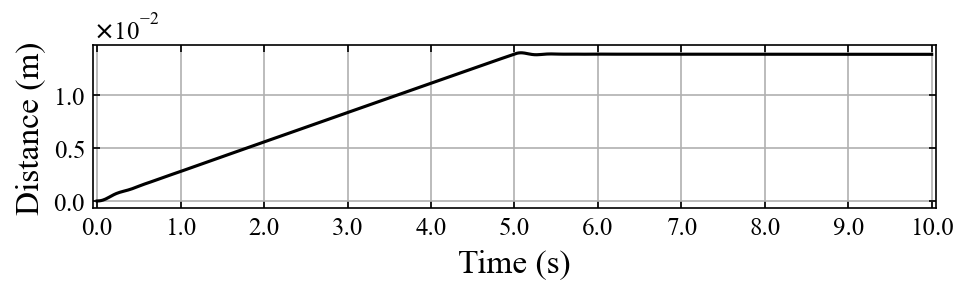

In [150]:
# 定义格式化函数，将步数转换为秒
def steps_to_seconds(x, pos):
    return f'{x / 100:.1f}'

fig, axs = plt.subplots(1, 1, figsize=(6.5, 2), dpi=150)
axs.plot(np.linalg.norm(sample_pos_np[:,:]-sample_pos_init, axis=1), c='k', lw=1.5)
# axs.set_title('Sample Node Movement', fontsize=18, fontname='Times New Roman')
axs.set_xlabel('Time (s)', fontsize=16, fontname='Times New Roman')
axs.set_ylabel('Distance (m)', fontsize=16, fontname='Times New Roman')
axs.set_xlim([-5, len(sample_pos_np)+4])

axs.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useLocale=False, useMathText=True)
axs.yaxis.offsetText.set_fontsize(12) 
axs.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
axs.grid('True')
axs.set_axisbelow(True)
axs.tick_params(axis='both', direction='in', top=True, right=True)

# 应用格式化函数到X轴
formatter = FuncFormatter(steps_to_seconds)
axs.xaxis.set_major_formatter(formatter)
axs.xaxis.set_major_locator(MultipleLocator(100))
axs.yaxis.set_major_locator(MultipleLocator(0.5e-2))

plt.tight_layout()
fig.savefig('sample_node.png', transparent=True, dpi=300, bbox_inches='tight')

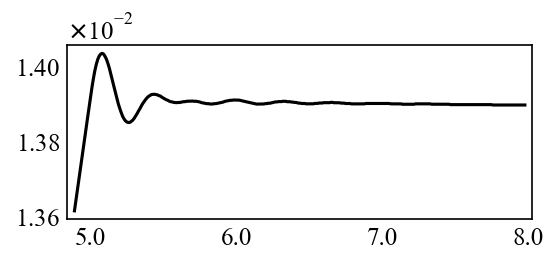

In [158]:
fig, axs = plt.subplots(1, 1, figsize=(4, 1.5), dpi=150)
axs.plot(np.arange(489, 799, 1), np.linalg.norm(sample_pos_np[489:799,:]-sample_pos_init, axis=1), linestyle='-', c='k', lw=1.5)
# axs.set_xlabel('Time (s)', fontsize=16, fontname='Times New Roman')
# axs.set_ylabel('Distance (m)', fontsize=14, fontname='Times New Roman')
axs.set_xlim([489-5, 799+4])
axs.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useLocale=False, useMathText=True)
axs.yaxis.offsetText.set_fontsize(12) 
axs.tick_params(axis='both', which='major', labelsize=12)  # 设置刻度标签大小
axs.set_axisbelow(True)
axs.tick_params(axis='both', direction='in', top=True, right=True)
axs.tick_params(axis='both', length=0)
# axs.grid('True')

# 应用格式化函数到X轴
formatter = FuncFormatter(steps_to_seconds)
axs.xaxis.set_major_formatter(formatter)

fig.savefig('sample_node_zoom.png', transparent=False, dpi=300, bbox_inches='tight')